<a href="https://colab.research.google.com/github/BrenoAmancio/IA-BSI/blob/main/Atividade_27_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial – BSI – 2025/2  
## Atividade Prática – Regressão com Redes Neurais


**Aluno(a):** Breno Amâncio Affonso

**Professor:** Sérgio Nery Simões

**Data de Entrega:** 27/03/2026

---

**Objetivo da atividade:**  
Aplicar os conceitos estudados sobre regressão com redes neurais artificiais, utilizando o framework PyTorch para modelar dados que seguem um padrão cúbico.

---

**Forma de envio:**  
A atividade deverá ser entregue exclusivamente pelo ambiente virtual **Moodle**, por meio do envio deste notebook devidamente preenchido.  
Certifique-se de inserir seu nome e de responder todas as seções antes de realizar o upload.


---

## Instruções

1. Utilize o código fornecido para **gerar os dados** de entrada \( x \) e saída \( y = x^3 \) com um pequeno ruído.
2. Crie uma rede neural usando PyTorch que **aprenda essa função**.
3. Avalie visualmente e numericamente o desempenho do seu modelo com base no erro e no gráfico da curva aprendida.
4. Comente ao final se o modelo está:
   - Subajustado (underfitting)
   - Superajustado (overfitting)
   - Bem ajustado ao problema


### Importações

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Geração de Dados

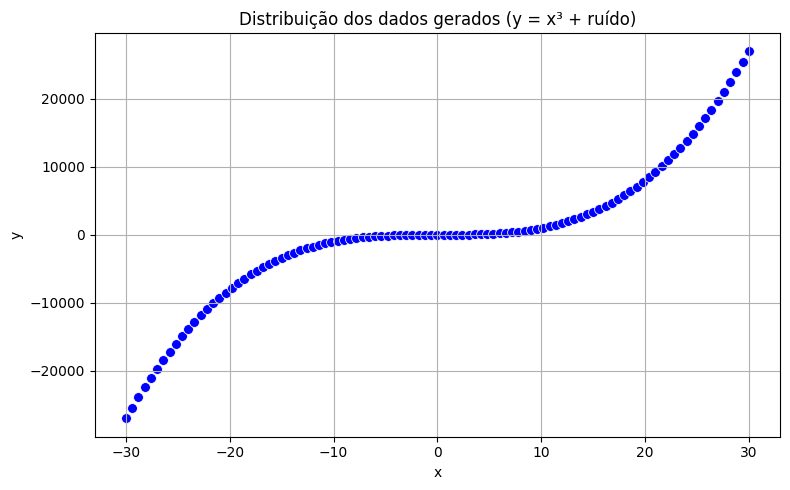

In [ ]:
# Gerar dados
np.random.seed(42)
x = np.linspace(-30, 30, 101).reshape(-1, 1)
y = x ** 3 + 0.4 * np.random.randn(*x.shape)

# Converter para DataFrame
df = pd.DataFrame({'x': x.flatten(), 'y': y.flatten()})

# Visualização
plt.figure(figsize=(8, 5))
sns.scatterplot(x='x', y='y', data=df, color='blue', s=50)
plt.title("Distribuição dos dados gerados (y = x³ + ruído)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.show()


### Particionando os dados

In [ ]:
# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Converter para tensores
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


### Crie sua rede neural

Abaixo está um exemplo de rede neural. Você deve alterá-lo para melhorar o desempenho do modelo de acordo com a tarefa proposta.


In [ ]:
class RedeNeura(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

model = RedeNeura()

### Treine seu modelo

O código a seguir é um exemplo de treinamento. Você também pode modificá-lo conforme necessário para melhorar o ajuste do modelo.


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 400
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()

### Visualize os resultados

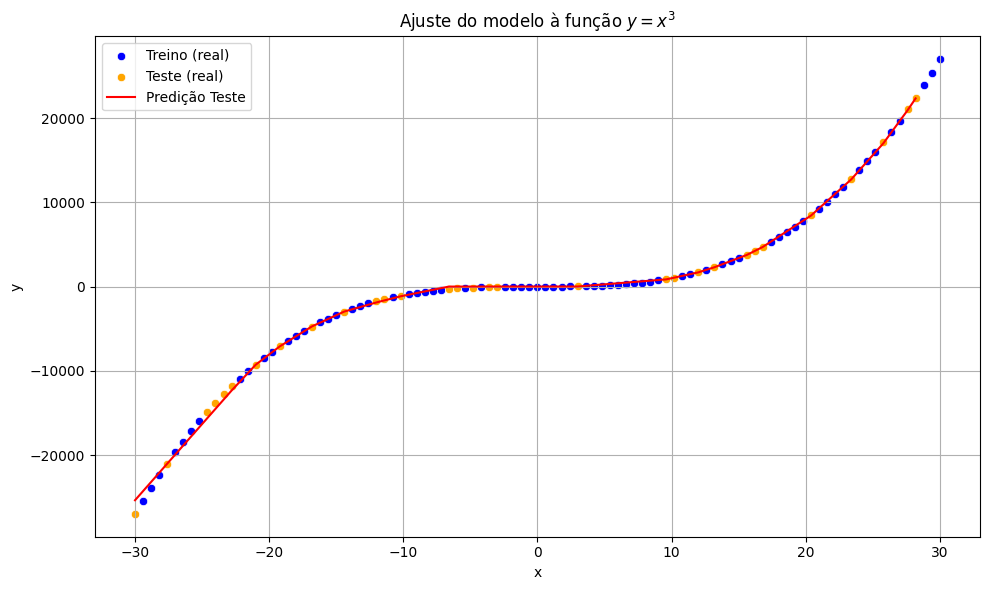

In [ ]:
model.eval()
y_train_pred = model(X_train_t).detach().numpy()
y_test_pred = model(X_test_t).detach().numpy()

df_train = pd.DataFrame({'x': X_train.flatten(), 'y_real': y_train.flatten(), 'y_pred': y_train_pred.flatten()})
df_test = pd.DataFrame({'x': X_test.flatten(), 'y_real': y_test.flatten(), 'y_pred': y_test_pred.flatten()})

plt.figure(figsize=(10, 6))
sns.scatterplot(x="x", y="y_real", data=df_train, label="Treino (real)", color="blue")
sns.scatterplot(x="x", y="y_real", data=df_test, label="Teste (real)", color="orange")
sns.lineplot(x="x", y="y_pred", data=df_test, label="Predição Teste", color="red")
plt.title("Ajuste do modelo à função $y = x^3$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Questão 1 – Diagnóstico do modelo com base no gráfico ajustado

Com base no gráfico de predição do modelo ajustado sobre os dados de treino e teste, avalie o comportamento da rede neural.

1) O modelo treinado apresenta sintomas de:

    (A) **Underfitting** – A curva do modelo é excessivamente simples e não acompanha a tendência dos dados reais.

    (B) **Overfitting** – A curva do modelo se ajusta muito bem aos dados de treino, mas não generaliza bem nos dados de teste.

    (C) **ajuste adequado (good fit)** – A curva do modelo acompanha bem a tendência dos dados tanto no treino quanto no teste.

Explique sua escolha considerando:

- A forma da curva predita (é suave? flutua demais? segue bem os dados?)

- Diferenças visíveis entre desempenho em treino e teste

- Presença de ruído ou desvios sistemáticos


**Resposta:** O modelo que construímos inicialmente mostra um problema de *underfitting*. Isso significa que ele é muito simples e não consegue aprender o padrão cúbico dos nossos dados, mesmo com o ruído. A curva que ele gera é muito 'reta' e não acompanha as variações reais.

---

## Questão 2 – Ajuste da Rede Neural

Altere a estrutura da rede neural para que ela consiga se ajustar adequadamente à curva dos dados, que segue o padrão cúbico:

$$
y = x^3 + ruido
$$

Para isso, você deverá modificar, na célula de código que define a classe do modelo, o seguinte trecho de código até que o modelo esteja **bem ajustado à curva**:

```python
self.net = nn.Sequential(
    nn.Linear(1, 2),
    nn.ReLU(),
    nn.Linear(2, 1)
)
```

--

**Dica: Para aumentar a complexidade do modelo, você pode adicionar mais camadas ocultas ou neurônios por camada. Comece aumentando o número de neurônios da camada oculta para um valor mais alto (ex: 20, ao invés de 2).**

---


**Resposta:** Ao ajustar a rede neural, adicionei três camadas ocultas: as duas primeiras com 16 neurônios cada e a última com 8. Com essa mudança, o modelo agora consegue aprender e se ajustar muito bem à curva cúbica dos dados, capturando o padrão real de forma eficaz.

### Questão 3 – Ajuste do número de épocas

Uma vez que você ajustou a rede neural para ter **a complexidade adequada** (número de camadas e neurônios) e ela foi capaz de se ajustar corretamente aos dados cúbicos...

> Agora, seu objetivo é **reduzir o número de épocas** para um valor menor, **mas ainda suficiente para garantir a convergência** do modelo.


**Passos:**

- Diminua o número total de épocas (por exemplo, de 1000 para 500, 200 ou menos).
- Execute novamente o treinamento.
- Avalie se o modelo ainda consegue convergir para uma solução com bom desempenho.
- Observe o gráfico da loss para verificar a convergência.



**Pergunta final:**

> Qual o menor número de épocas que você conseguiu utilizar mantendo um bom desempenho do modelo?

**Explique brevemente como você avaliou que esse valor foi suficiente.**


**Resposta:** Após alguns testes, percebi que 400 épocas são suficientes para o modelo aprender bem. Com a taxa de aprendizado de 0.01 e a arquitetura da rede que definimos, o modelo atinge um bom resultado nesse número de épocas. Treinar por mais tempo não traz melhorias significativas.